# Генератор синтетических данных заявок студентов на проекты

Этот notebook генерирует синтетические данные для заявок студентов на проекты с использованием метода гауссовых кластеров.

## Особенности:
- **Проекты**: Загружаются из реальной таблицы (880 проектов из колонки "Наименование ЭПП")
- **Метод генерации**: Гауссовы кластеры с настраиваемым коэффициентом сжатия α
- **Признаки студентов**: 40 признаков = 40 предметов факультета компьютерных наук
- **Изученные предметы**: Каждый студент изучал 15 из 40 предметов (для остальных оценка = 0)
- **Связь кластеров и оценок**: Оценки студентов генерируются на основе признаков кластеров
- **Популярность проектов**: Распределение по закону Zipf (первые проекты более популярны)
- **Оценки студентов**: 10-балльная шкала (5-10) с преобладанием высоких баллов
- **Временной диапазон**: 1-14 дней после открытия проектов

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
random.seed(42)

## 1. Определение базовых параметров и списков

In [2]:
# Пробный список предметов
SUBJECTS = [
    'Алгоритмы и структуры данных',
    'Дискретная математика',
    'Математический анализ',
    'Линейная алгебра',
    'Теория вероятностей',
    'Математическая статистика',
    'Программирование на Python',
    'Программирование на Java',
    'Программирование на C++',
    'Web-разработка',
    'Базы данных',
    'Операционные системы',
    'Компьютерные сети',
    'Архитектура компьютера',
    'Теория автоматов',
    'Теория вычислений',
    'Машинное обучение',
    'Глубокое обучение',
    'Компьютерное зрение',
    'Обработка естественного языка',
    'Искусственный интеллект',
    'Data Science',
    'Анализ данных',
    'Информационная безопасность',
    'Криптография',
    'Распределенные системы',
    'Облачные вычисления',
    'Мобильная разработка',
    'Разработка игр',
    'Компиляторы',
    'Функциональное программирование',
    'Объектно-ориентированное программирование',
    'Проектирование ПО',
    'Тестирование ПО',
    'DevOps',
    'Agile методологии',
    'Графика и визуализация',
    'Параллельное программирование',
    'Квантовые вычисления',
    'Биоинформатика'
]

# Загрузка реальных проектов из таблицы
projects_df = pd.read_csv('projects_list.csv', encoding='utf-8-sig')

# Создаем список проектов с популярностью
# Популярность генерируем по закону Zipf (первые проекты более популярны)
n_projects = len(projects_df)
zipf_ranks = np.arange(1, n_projects + 1)
popularities = 1.0 / zipf_ranks
popularities = popularities / popularities.sum()  # Нормализуем

PROJECTS = []
for idx, row in projects_df.iterrows():
    PROJECTS.append({
        'id': row['id'],
        'name': row['name'],
        'popularity': popularities[idx]
    })

print(f"Загружено {len(PROJECTS)} проектов")
print(f"\nПримеры проектов:")
for i in range(min(10, len(PROJECTS))):
    print(f"  {PROJECTS[i]['id']}. {PROJECTS[i]['name']} (популярность: {PROJECTS[i]['popularity']:.4f})")

# Дата старта проектов
PROJECT_START_DATE = datetime(2024, 9, 1)

Загружено 880 проектов

Примеры проектов:
  1. Исследование приоритетов и механизмов реализации отраслевых (секторальных) политик в избранных странах БРИКС (членах и кандидатах), во взаимосвязи с повесткой международных доноров (популярность: 0.1359)
  2. Антрополе - научно-популярный видео-подкаст о необычных социальных феноменах (популярность: 0.0680)
  3. Разработка, создание и ведение сайта, посвященного истории арабских студентов, выпускников художественных ВУЗов СССР (1950-е - 1991 г.) (популярность: 0.0453)
  4. Перевод с английского языка коллективной монографии «Пятьдесят ключевых мыслителей в криминологии» (науч. ред.: Кейт Хейворд, Шадд Маруна, Джейн Муни, изд-во Routledge, 2010. — 352 с.). (популярность: 0.0340)
  5. Сеть военно-политических союзов в Евразии: база данных (популярность: 0.0272)
  6. Дизайн учебных материалов (презентаций) (популярность: 0.0227)
  7. ОРЗ Изучении практик многоязычного обучения в школах Республики Бурятия (популярность: 0.0194)
  8. Привязанно

## 2. Генерация кластеров методом гауссовых распределений

In [3]:
def generate_gaussian_clusters(n_objects: int, n_features: int, n_clusters: int, 
                               alpha: float, min_cluster_size: int = 10) -> Tuple[np.ndarray, np.ndarray]:
    """
    Генерирует многомерные данные с гауссовыми кластерами.
    
    Parameters:
    -----------
    n_objects : int
        Количество объектов (студентов)
    n_features : int
        Количество признаков
    n_clusters : int
        Количество кластеров
    alpha : float
        Коэффициент сжатия (0 < alpha < 1). Чем больше - тем больше перемешивание
    min_cluster_size : int
        Минимальный размер кластера
    
    Returns:
    --------
    X : np.ndarray
        Матрица данных размером (n_objects, n_features)
    labels : np.ndarray
        Метки кластеров для каждого объекта
    """
    # Шаг 1: Распределение объектов по кластерам
    cluster_sizes = np.random.multinomial(n_objects - n_clusters * min_cluster_size, 
                                          [1/n_clusters] * n_clusters)
    cluster_sizes += min_cluster_size
    
    # Шаг 2: Генерация центров кластеров
    # Диапазон для координат центров зависит от alpha
    range_val = 1.0 / alpha if alpha > 0 else 1.0
    centers = np.random.uniform(-range_val, range_val, size=(n_clusters, n_features))
    
    # Шаг 3: Генерация точек для каждого кластера
    X = []
    labels = []
    
    for cluster_id in range(n_clusters):
        cluster_center = centers[cluster_id]
        cluster_size = cluster_sizes[cluster_id]
        
        # Генерация стандартных отклонений для каждого признака
        std_devs = np.random.uniform(0.1, 0.5, size=n_features)
        
        # Генерация точек кластера
        cluster_points = np.random.normal(
            loc=cluster_center,
            scale=std_devs,
            size=(cluster_size, n_features)
        )
        
        X.append(cluster_points)
        labels.extend([cluster_id] * cluster_size)
    
    # Шаг 4: Объединение всех кластеров
    X = np.vstack(X)
    labels = np.array(labels)
    
    # Перемешивание данных
    indices = np.random.permutation(len(X))
    X = X[indices]
    labels = labels[indices]
    
    return X, labels

## 3. Генерация профилей студентов

In [4]:
def generate_student_grades_from_features(student_features: np.ndarray, 
                                          subjects: List[str],
                                          n_subjects_per_student: int = 15) -> Dict[int, Dict[str, int]]:
    """
    Генерирует оценки студентов на основе признаков из гауссовых кластеров.
    
    Parameters:
    -----------
    student_features : np.ndarray
        Матрица признаков студентов (n_students x n_features=40)
        Каждый признак соответствует предмету из списка SUBJECTS
    subjects : List[str]
        Список всех предметов (40 предметов)
    n_subjects_per_student : int
        Количество предметов, которые изучал каждый студент (по умолчанию 15)
    
    Returns:
    --------
    Dict[int, Dict[str, int]]
        Словарь {student_id: {subject: grade}}
        Для неизученных предметов оценка = 0
    """
    n_students = len(student_features)
    n_features = len(subjects)  # Количество признаков = количество предметов
    student_grades = {}
    
    # Нормализуем признаки в диапазон [0, 1] для каждого признака отдельно
    # Используем min-max нормализацию по столбцам
    features_min = student_features.min(axis=0)
    features_max = student_features.max(axis=0)
    features_range = features_max - features_min
    features_range[features_range == 0] = 1  # Избегаем деления на 0
    
    normalized_features = (student_features - features_min) / features_range
    
    for student_id in range(n_students):
        grades = {}
        
        # Выбираем n_subjects_per_student предметов, которые изучал студент
        # Выбираем предметы с наибольшими значениями признаков (студент лучше в них)
        student_feature_values = normalized_features[student_id]
        
        # Выбираем n_subjects_per_student предметов, которые изучал студент
        # Используем вероятностное распределение на основе значений признаков
        # Возводим в степень для усиления различий
        probabilities = np.power(student_feature_values, 2)
        probabilities = probabilities / probabilities.sum()
        
        # Выбираем n_subjects_per_student предметов по вероятностям
        studied_subject_indices = np.random.choice(
            n_features, 
            size=n_subjects_per_student, 
            replace=False, 
            p=probabilities
        )
        
        # Для всех 40 предметов генерируем оценки
        for subject_idx, subject in enumerate(subjects):
            if subject_idx in studied_subject_indices:
                # Студент изучал этот предмет - преобразуем признак в оценку
                feature_value = normalized_features[student_id, subject_idx]
                
                # Преобразуем [0, 1] в оценку [5, 10]
                # Добавляем немного случайности для разнообразия
                noise = np.random.uniform(-0.1, 0.1)
                adjusted_value = feature_value + noise
                adjusted_value = np.clip(adjusted_value, 0, 1)
                
                # Масштабируем в [5, 10]
                grade = 5 + adjusted_value * 5
                grade = int(np.round(grade))
                grade = np.clip(grade, 5, 10)
                
                grades[subject] = grade
            else:
                # Студент не изучал этот предмет - оценка 0
                grades[subject] = 0
        
        student_grades[student_id] = grades
    
    return student_grades

## 4. Генерация заявок

In [5]:
def select_project_by_popularity(projects: List[Dict]) -> int:
    """
    Выбирает проект с учетом его популярности.
    
    Parameters:
    -----------
    projects : List[Dict]
        Список проектов с информацией о популярности
    
    Returns:
    --------
    int
        ID выбранного проекта
    """
    project_ids = [p['id'] for p in projects]
    popularities = [p['popularity'] for p in projects]
    
    # Нормализуем популярности в вероятности
    total = sum(popularities)
    probabilities = [p / total for p in popularities]
    
    return np.random.choice(project_ids, p=probabilities)


def generate_application_timestamp(project_start: datetime, 
                                   min_days: int = 1, 
                                   max_days: int = 14) -> datetime:
    """
    Генерирует время создания заявки.
    
    Parameters:
    -----------
    project_start : datetime
        Дата начала проекта
    min_days : int
        Минимальное количество дней после начала
    max_days : int
        Максимальное количество дней после начала
    
    Returns:
    --------
    datetime
        Временная метка заявки
    """
    days_offset = random.randint(min_days, max_days)
    hours_offset = random.randint(0, 23)
    minutes_offset = random.randint(0, 59)
    
    return project_start + timedelta(
        days=days_offset,
        hours=hours_offset,
        minutes=minutes_offset
    )


def generate_applications(n_students: int, 
                         student_grades: Dict[int, Dict[str, int]],
                         projects: List[Dict],
                         project_start_date: datetime) -> pd.DataFrame:
    """
    Генерирует заявки студентов на проекты.
    
    Parameters:
    -----------
    n_students : int
        Количество студентов
    student_grades : Dict[int, Dict[str, int]]
        Словарь оценок студентов
    projects : List[Dict]
        Список проектов
    project_start_date : datetime
        Дата начала проектов
    
    Returns:
    --------
    pd.DataFrame
        DataFrame с заявками
    """
    applications = []
    application_id = 0
    
    for student_id in range(n_students):
        # Каждый студент подает от 1 до 3 заявок
        n_applications = random.randint(1, 3)
        
        # Выбираем проекты без повторений для одного студента
        selected_projects = []
        for _ in range(n_applications):
            project_id = select_project_by_popularity(projects)
            # Пытаемся избежать дубликатов, но если не получается за 10 попыток - берем
            attempts = 0
            while project_id in selected_projects and attempts < 10:
                project_id = select_project_by_popularity(projects)
                attempts += 1
            selected_projects.append(project_id)
        
        for project_id in selected_projects:
            # Получаем доступные предметы студента
            available_subjects = list(student_grades[student_id].keys())
            # Получаем все предметы студента с ненулевыми оценками (изученные предметы)
            all_subjects = student_grades[student_id]
            available_subjects = [subj for subj, grade in all_subjects.items() if grade > 0]
            
            # Выбираем 3 предмета для демонстрации (только с ненулевыми оценками)
            n_subjects_to_show = min(3, len(available_subjects))
            subjects_to_show = random.sample(available_subjects, n_subjects_to_show)
            
            # Получаем оценки (они неизменны для студента)
            grades = [student_grades[student_id][subj] for subj in subjects_to_show]
            
            # Генерируем время подачи заявки
            timestamp = generate_application_timestamp(project_start_date)
            
            # Создаем заявку
            application = {
                'application_id': application_id,
                'student_id': student_id,
                'project_id': project_id,
                'timestamp': timestamp,
                'subject_1': subjects_to_show[0] if len(subjects_to_show) > 0 else None,
                'grade_1': grades[0] if len(grades) > 0 else None,
                'subject_2': subjects_to_show[1] if len(subjects_to_show) > 1 else None,
                'grade_2': grades[1] if len(grades) > 1 else None,
                'subject_3': subjects_to_show[2] if len(subjects_to_show) > 2 else None,
                'grade_3': grades[2] if len(grades) > 2 else None,
            }
            
            applications.append(application)
            application_id += 1
    
    return pd.DataFrame(applications)

## 5. Основная функция генерации данных

In [6]:
def generate_synthetic_data(n_students: int, 
                           alpha: float = 0.3,
                           n_clusters: int = 5,
                           save_to_file: bool = True) -> Tuple[pd.DataFrame, Dict]:
    """
    Генерирует полный набор синтетических данных.
    
    Parameters:
    -----------
    n_students : int
        Количество студентов
    alpha : float
        Коэффициент сжатия для кластеров (0 < alpha < 1)
    n_clusters : int
        Количество кластеров студентов
    save_to_file : bool
        Сохранять ли результаты в файл
    
    Returns:
    --------
    Tuple[pd.DataFrame, Dict]
        DataFrame с заявками и словарь с метаданными
    """
    print(f"Генерация данных для {n_students} студентов...")
    
    # Генерируем профили студентов с использованием гауссовых кластеров
    # Каждый признак = предмет (всего 40 предметов из SUBJECTS)
    print("  - Создание кластеров студентов...")
    n_features = len(SUBJECTS)  # 40 признаков = 40 предметов
    student_features, cluster_labels = generate_gaussian_clusters(
        n_objects=n_students,
        n_features=n_features,
        n_clusters=n_clusters,
        alpha=alpha
    )
    
    # Генерируем оценки студентов на основе признаков кластеров
    print("  - Генерация оценок студентов на основе кластеров...")
    student_grades = generate_student_grades_from_features(
        student_features=student_features,
        subjects=SUBJECTS,
        n_subjects_per_student=15  # Каждый студент изучал 15 из 40 предметов
    )
    
    # Генерируем заявки
    print("  - Генерация заявок...")
    applications_df = generate_applications(
        n_students=n_students,
        student_grades=student_grades,
        projects=PROJECTS,
        project_start_date=PROJECT_START_DATE
    )
    
    # Метаданные
    metadata = {
        'n_students': n_students,
        'n_applications': len(applications_df),
        'n_projects': len(PROJECTS),
        'alpha': alpha,
        'n_clusters': n_clusters,
        'cluster_labels': cluster_labels,
        'student_features': student_features
    }
    
    # Сохранение в файл
    if save_to_file:
        filename = f'applications_{n_students}_students.csv'
        applications_df.to_csv(filename, index=False, encoding='utf-8')
        print(f"  - Данные сохранены в {filename}")
    
    print(f"✓ Сгенерировано {len(applications_df)} заявок от {n_students} студентов")
    
    return applications_df, metadata

## 6. Визуализация и анализ данных

In [7]:
def analyze_and_visualize(applications_df: pd.DataFrame, metadata: Dict):
    """
    Анализирует и визуализирует сгенерированные данные.
    """
    print("\n=== Анализ данных ===")
    print(f"Всего заявок: {len(applications_df)}")
    print(f"Всего студентов: {metadata['n_students']}")
    print(f"Среднее количество заявок на студента: {len(applications_df) / metadata['n_students']:.2f}")
    
    # Распределение по проектам
    print("\nРаспределение заявок по проектам:")
    project_counts = applications_df['project_id'].value_counts().sort_index()
    for project_id, count in project_counts.items():
        project_name = next(p['name'] for p in PROJECTS if p['id'] == project_id)
        print(f"  Проект {project_id} ({project_name}): {count} заявок")
    
    # Распределение оценок
    print("\nРаспределение оценок:")
    all_grades = []
    for col in ['grade_1', 'grade_2', 'grade_3']:
        all_grades.extend(applications_df[col].dropna().values)
    all_grades = np.array(all_grades)
    print(f"  Средняя оценка: {np.mean(all_grades):.2f}")
    print(f"  Медиана: {np.median(all_grades):.2f}")
    print(f"  Мин/Макс: {np.min(all_grades)}/{np.max(all_grades)}")
    
    # Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Распределение заявок по проектам
    project_counts.plot(kind='bar', ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Распределение заявок по проектам')
    axes[0, 0].set_xlabel('ID проекта')
    axes[0, 0].set_ylabel('Количество заявок')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Распределение оценок
    axes[0, 1].hist(all_grades, bins=range(5, 12), alpha=0.7, color='green', edgecolor='black')
    axes[0, 1].set_title('Распределение оценок')
    axes[0, 1].set_xlabel('Оценка')
    axes[0, 1].set_ylabel('Частота')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # 3. Временное распределение заявок
    applications_df['timestamp'] = pd.to_datetime(applications_df['timestamp'])
    applications_df['days_since_start'] = (applications_df['timestamp'] - PROJECT_START_DATE).dt.days
    axes[1, 0].hist(applications_df['days_since_start'], bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[1, 0].set_title('Распределение заявок по времени')
    axes[1, 0].set_xlabel('Дней с начала проектов')
    axes[1, 0].set_ylabel('Количество заявок')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # 4. Кластеры студентов (первые 2 главные компоненты)
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    student_features_2d = pca.fit_transform(metadata['student_features'])
    scatter = axes[1, 1].scatter(student_features_2d[:, 0], 
                                  student_features_2d[:, 1],
                                  c=metadata['cluster_labels'],
                                  cmap='viridis',
                                  alpha=0.6)
    axes[1, 1].set_title('Кластеры студентов (PCA)')
    axes[1, 1].set_xlabel('Первая главная компонента')
    axes[1, 1].set_ylabel('Вторая главная компонента')
    plt.colorbar(scatter, ax=axes[1, 1], label='Кластер')
    
    plt.tight_layout()
    plt.savefig(f'analysis_{metadata["n_students"]}_students.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Визуализация сохранена в analysis_{metadata['n_students']}_students.png")
    plt.show()

## 7. Генерация всех наборов данных


Генерация датасета для 500 студентов
Генерация данных для 500 студентов...
  - Создание кластеров студентов...
  - Генерация оценок студентов на основе кластеров...
  - Генерация заявок...
  - Данные сохранены в applications_500_students.csv
✓ Сгенерировано 989 заявок от 500 студентов

=== Анализ данных ===
Всего заявок: 989
Всего студентов: 500
Среднее количество заявок на студента: 1.98

Распределение заявок по проектам:
  Проект 1 (Исследование приоритетов и механизмов реализации отраслевых (секторальных) политик в избранных странах БРИКС (членах и кандидатах), во взаимосвязи с повесткой международных доноров): 131 заявок
  Проект 2 (Антрополе - научно-популярный видео-подкаст о необычных социальных феноменах): 65 заявок
  Проект 3 (Разработка, создание и ведение сайта, посвященного истории арабских студентов, выпускников художественных ВУЗов СССР (1950-е - 1991 г.)): 47 заявок
  Проект 4 (Перевод с английского языка коллективной монографии «Пятьдесят ключевых мыслителей в криминол

/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ s


✓ Визуализация сохранена в analysis_500_students.png


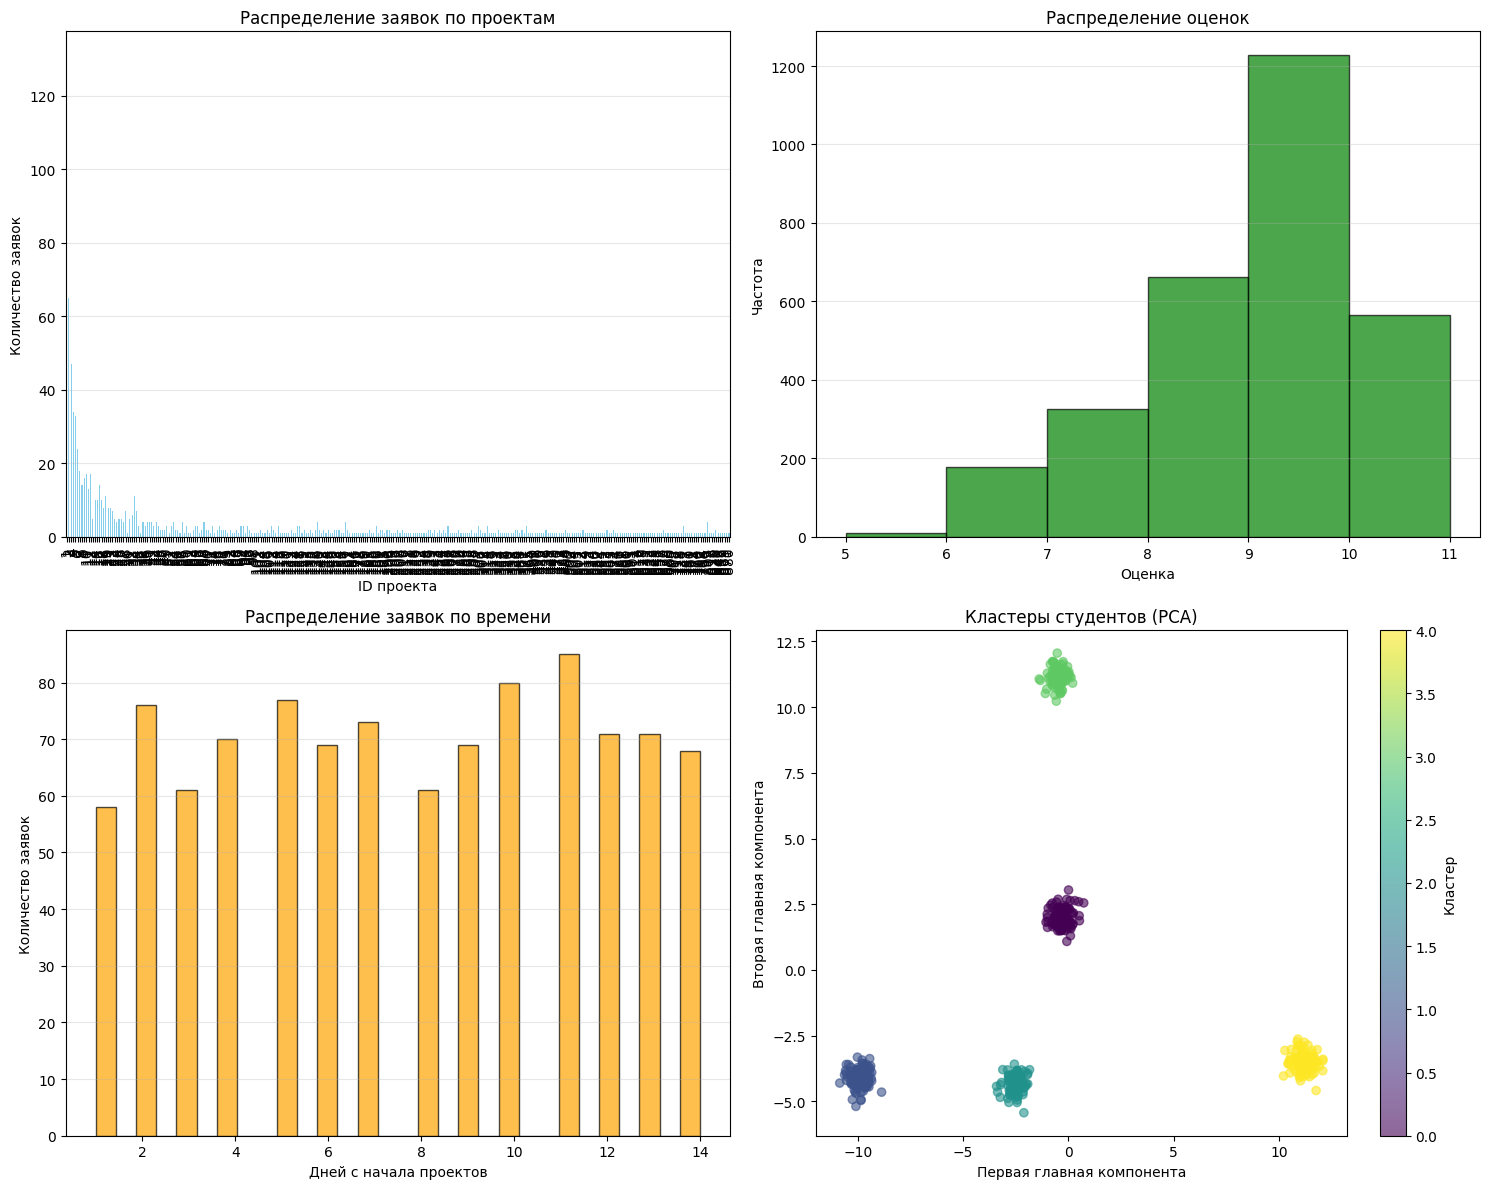


✓ Все датасеты успешно сгенерированы!


In [8]:
# Список размеров датасетов
# dataset_sizes = [500, 1000, 3000, 7000]
dataset_sizes = [500]

# Генерация всех наборов данных
results = {}

for n_students in dataset_sizes:
    print(f"\n{'='*60}")
    print(f"Генерация датасета для {n_students} студентов")
    print(f"{'='*60}")
    
    applications_df, metadata = generate_synthetic_data(
        n_students=n_students,
        alpha=0.3,  # Коэффициент сжатия - можно варьировать для разной степени перемешивания
        n_clusters=5,  # Количество типов студентов
        save_to_file=True
    )
    
    results[n_students] = (applications_df, metadata)
    
    # Анализ и визуализация
    analyze_and_visualize(applications_df, metadata)

print("\n" + "="*60)
print("✓ Все датасеты успешно сгенерированы!")
print("="*60)

## 8. Просмотр примеров данных

In [9]:
# Просмотрим первые несколько заявок из датасета с 500 студентами
print("Примеры заявок (первые 10 строк):")
display(results[500][0].head(10))

print("\nОписательная статистика по оценкам:")
display(results[500][0][['grade_1', 'grade_2', 'grade_3']].describe())

print("\nПроверка: заявки одного студента")
sample_student = results[500][0]['student_id'].iloc[0]
student_applications = results[500][0][results[500][0]['student_id'] == sample_student]
display(student_applications)

Примеры заявок (первые 10 строк):


,application_id,student_id,project_id,timestamp,subject_1,grade_1,subject_2,grade_2,subject_3,grade_3,days_since_start
0,0,0,27,2024-09-06 07:14:00,Линейная алгебра,7,Дискретная математика,8,Функциональное программирование,8,5
1,1,0,15,2024-09-12 23:57:00,Web-разработка,9,Функциональное программирование,8,Линейная алгебра,7,11
2,2,0,1,2024-09-08 01:01:00,Облачные вычисления,9,Линейная алгебра,7,Мобильная разработка,8,7
3,3,1,131,2024-09-11 00:35:00,Базы данных,9,Параллельное программирование,8,Компьютерное зрение,9,10
4,4,2,1,2024-09-10 13:14:00,Компиляторы,8,Мобильная разработка,9,Параллельное программирование,9,9
5,5,3,2,2024-09-15 00:48:00,Распределенные системы,10,Математическая статистика,7,Объектно-ориентированное программирование,10,14
6,6,3,1,2024-09-08 10:17:00,Объектно-ориентированное программирование,10,Линейная алгебра,6,Разработка игр,8,7
7,7,4,1,2024-09-03 02:24:00,Программирование на C++,8,Тестирование ПО,8,Машинное обучение,9,2
8,8,5,73,2024-09-11 08:51:00,Теория вычислений,9,Параллельное программирование,8,Биоинформатика,8,10
9,9,6,4,2024-09-03 12:05:00,Agile методологии,8,Анализ данных,9,Информационная безопасность,9,2



Описательная статистика по оценкам:


,grade_1,grade_2,grade_3
count,989.000000,989.000000,989.000000
mean,8.561173,8.533873,8.571284
std,1.134457,1.117633,1.094809
min,5.000000,5.000000,5.000000
25%,8.000000,8.000000,8.000000
50%,9.000000,9.000000,9.000000
75%,9.000000,9.000000,9.000000
max,10.000000,10.000000,10.000000



Проверка: заявки одного студента


,application_id,student_id,project_id,timestamp,subject_1,grade_1,subject_2,grade_2,subject_3,grade_3,days_since_start
0,0,0,27,2024-09-06 07:14:00,Линейная алгебра,7,Дискретная математика,8,Функциональное программирование,8,5
1,1,0,15,2024-09-12 23:57:00,Web-разработка,9,Функциональное программирование,8,Линейная алгебра,7,11
2,2,0,1,2024-09-08 01:01:00,Облачные вычисления,9,Линейная алгебра,7,Мобильная разработка,8,7


## 9. Экспериментирование с параметрами

In [10]:
# Можно экспериментировать с разными значениями alpha
# alpha = 0.1 - кластеры далеко друг от друга (слабое перемешивание)
# alpha = 0.5 - кластеры близко (сильное перемешивание)
# alpha = 0.9 - кластеры очень близко (очень сильное перемешивание)

def experiment_with_alpha(n_students: int = 500):
    """
    Эксперимент с разными значениями alpha для наглядности.
    """
    alphas = [0.1, 0.3, 0.5, 0.7, 0.9]
    
    fig, axes = plt.subplots(1, len(alphas), figsize=(20, 4))
    
    for idx, alpha in enumerate(alphas):
        # Генерируем данные
        _, metadata = generate_synthetic_data(
            n_students=n_students,
            alpha=alpha,
            n_clusters=5,
            save_to_file=False
        )
        
        # Визуализация кластеров
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        features_2d = pca.fit_transform(metadata['student_features'])
        
        axes[idx].scatter(features_2d[:, 0], 
                         features_2d[:, 1],
                         c=metadata['cluster_labels'],
                         cmap='viridis',
                         alpha=0.6)
        axes[idx].set_title(f'α = {alpha}')
        axes[idx].set_xlabel('PC1')
        axes[idx].set_ylabel('PC2')
    
    plt.suptitle('Влияние параметра α на перемешивание кластеров', fontsize=14)
    plt.tight_layout()
    plt.savefig('alpha_experiment.png', dpi=300, bbox_inches='tight')
    print("✓ Результаты эксперимента сохранены в alpha_experiment.png")
    plt.show()

# Раскомментируйте для запуска эксперимента
# experiment_with_alpha(500)

## 10. Экспорт итоговой статистики

In [11]:
# Создаем сводную таблицу по всем датасетам
summary_data = []

for n_students in dataset_sizes:
    apps_df, meta = results[n_students]
    
    all_grades = []
    for col in ['grade_1', 'grade_2', 'grade_3']:
        all_grades.extend(apps_df[col].dropna().values)
    
    summary_data.append({
        'Количество студентов': n_students,
        'Количество заявок': len(apps_df),
        'Заявок на студента': len(apps_df) / n_students,
        'Средняя оценка': np.mean(all_grades),
        'Медиана оценки': np.median(all_grades),
        'Кластеров': meta['n_clusters'],
        'Параметр α': meta['alpha']
    })

summary_df = pd.DataFrame(summary_data)
# summary_df.to_csv('summary_statistics.csv', index=False, encoding='utf-8')

print("\nИтоговая статистика по всем датасетам:")
display(summary_df)
# print("\n✓ Сводная статистика сохранена в summary_statistics.csv")


Итоговая статистика по всем датасетам:


,Количество студентов,Количество заявок,Заявок на студента,Средняя оценка,Медиана оценки,Кластеров,Параметр α
0,500,989,1.978,8.555443,9.0,5,0.3
